In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from scipy import stats

In [2]:
def season(month):
    if month in [12, 1, 2, 3]:
        return 1
    if month in [4, 5, 6]:
        return 2
    if month in [7, 8, 9]:
        return 3
    return 4

def water_year(dates):
    return np.where(dates.dt.month >= 10, dates.dt.year + 1, dates.dt.year)

def fit_regression(x, y):
    slope, intercept, _, p_value, _ = stats.linregress(x, y)
    return intercept, slope, p_value

def regression_lines(var):
    df = series[series['variable'] == var].dropna(subset=['WY', 'value']).sort_values('WY')
    x = df['WY'].to_numpy(float)
    y = df['value'].to_numpy(float)
    cps = breakpoints[(breakpoints['variable'] == var) & (breakpoints['method'] == 'regression')]['bp_year'].tolist()
    if not cps:
        intercept, slope, p_value = fit_regression(x, y)
        xx = np.linspace(x.min(), x.max(), 200)
        return [(xx, intercept + slope * xx, p_value)]
    lines = []
    bounds = [x.min()] + [float(cp) for cp in cps] + [x.max()]
    for left, right in zip(bounds[:-1], bounds[1:]):
        mask = (x >= left) & (x <= right)
        if mask.sum() < 2:
            continue
        intercept, slope, p_value = fit_regression(x[mask], y[mask])
        xx = np.linspace(x[mask].min(), x[mask].max(), 200)
        lines.append((xx, intercept + slope * xx, p_value))
    return lines

def variance_bands(var):
    df = series[series['variable'] == var].dropna(subset=['WY', 'value']).sort_values('WY')
    x = df['WY'].to_numpy(float)
    y = df['value'].to_numpy(float)
    cps = breakpoints[(breakpoints['variable'] == var) & (breakpoints['method'] == 'variance')]['bp_year'].tolist()
    if not cps:
        return [(x.min(), x.max(), y.mean(), y.std(ddof=1) if len(y) > 1 else 0)]
    bands = []
    bounds = [x.min()] + [float(cp) for cp in cps] + [x.max()]
    for left, right in zip(bounds[:-1], bounds[1:]):
        mask = (x >= left) & (x <= right)
        if mask.sum() >= 2:
            bands.append((left, right, y[mask].mean(), y[mask].std(ddof=1)))
    return bands

results = pd.read_csv('../Data/msn_cpd_results.csv')
results['variable'] = results['variable'].astype(str)

series = results[results['type'] == 'series'][['variable', 'WY', 'value']].reset_index(drop=True)
breakpoints = results[results['type'] == 'breakpoint'][['variable', 'method', 'bp_year']].reset_index(drop=True)

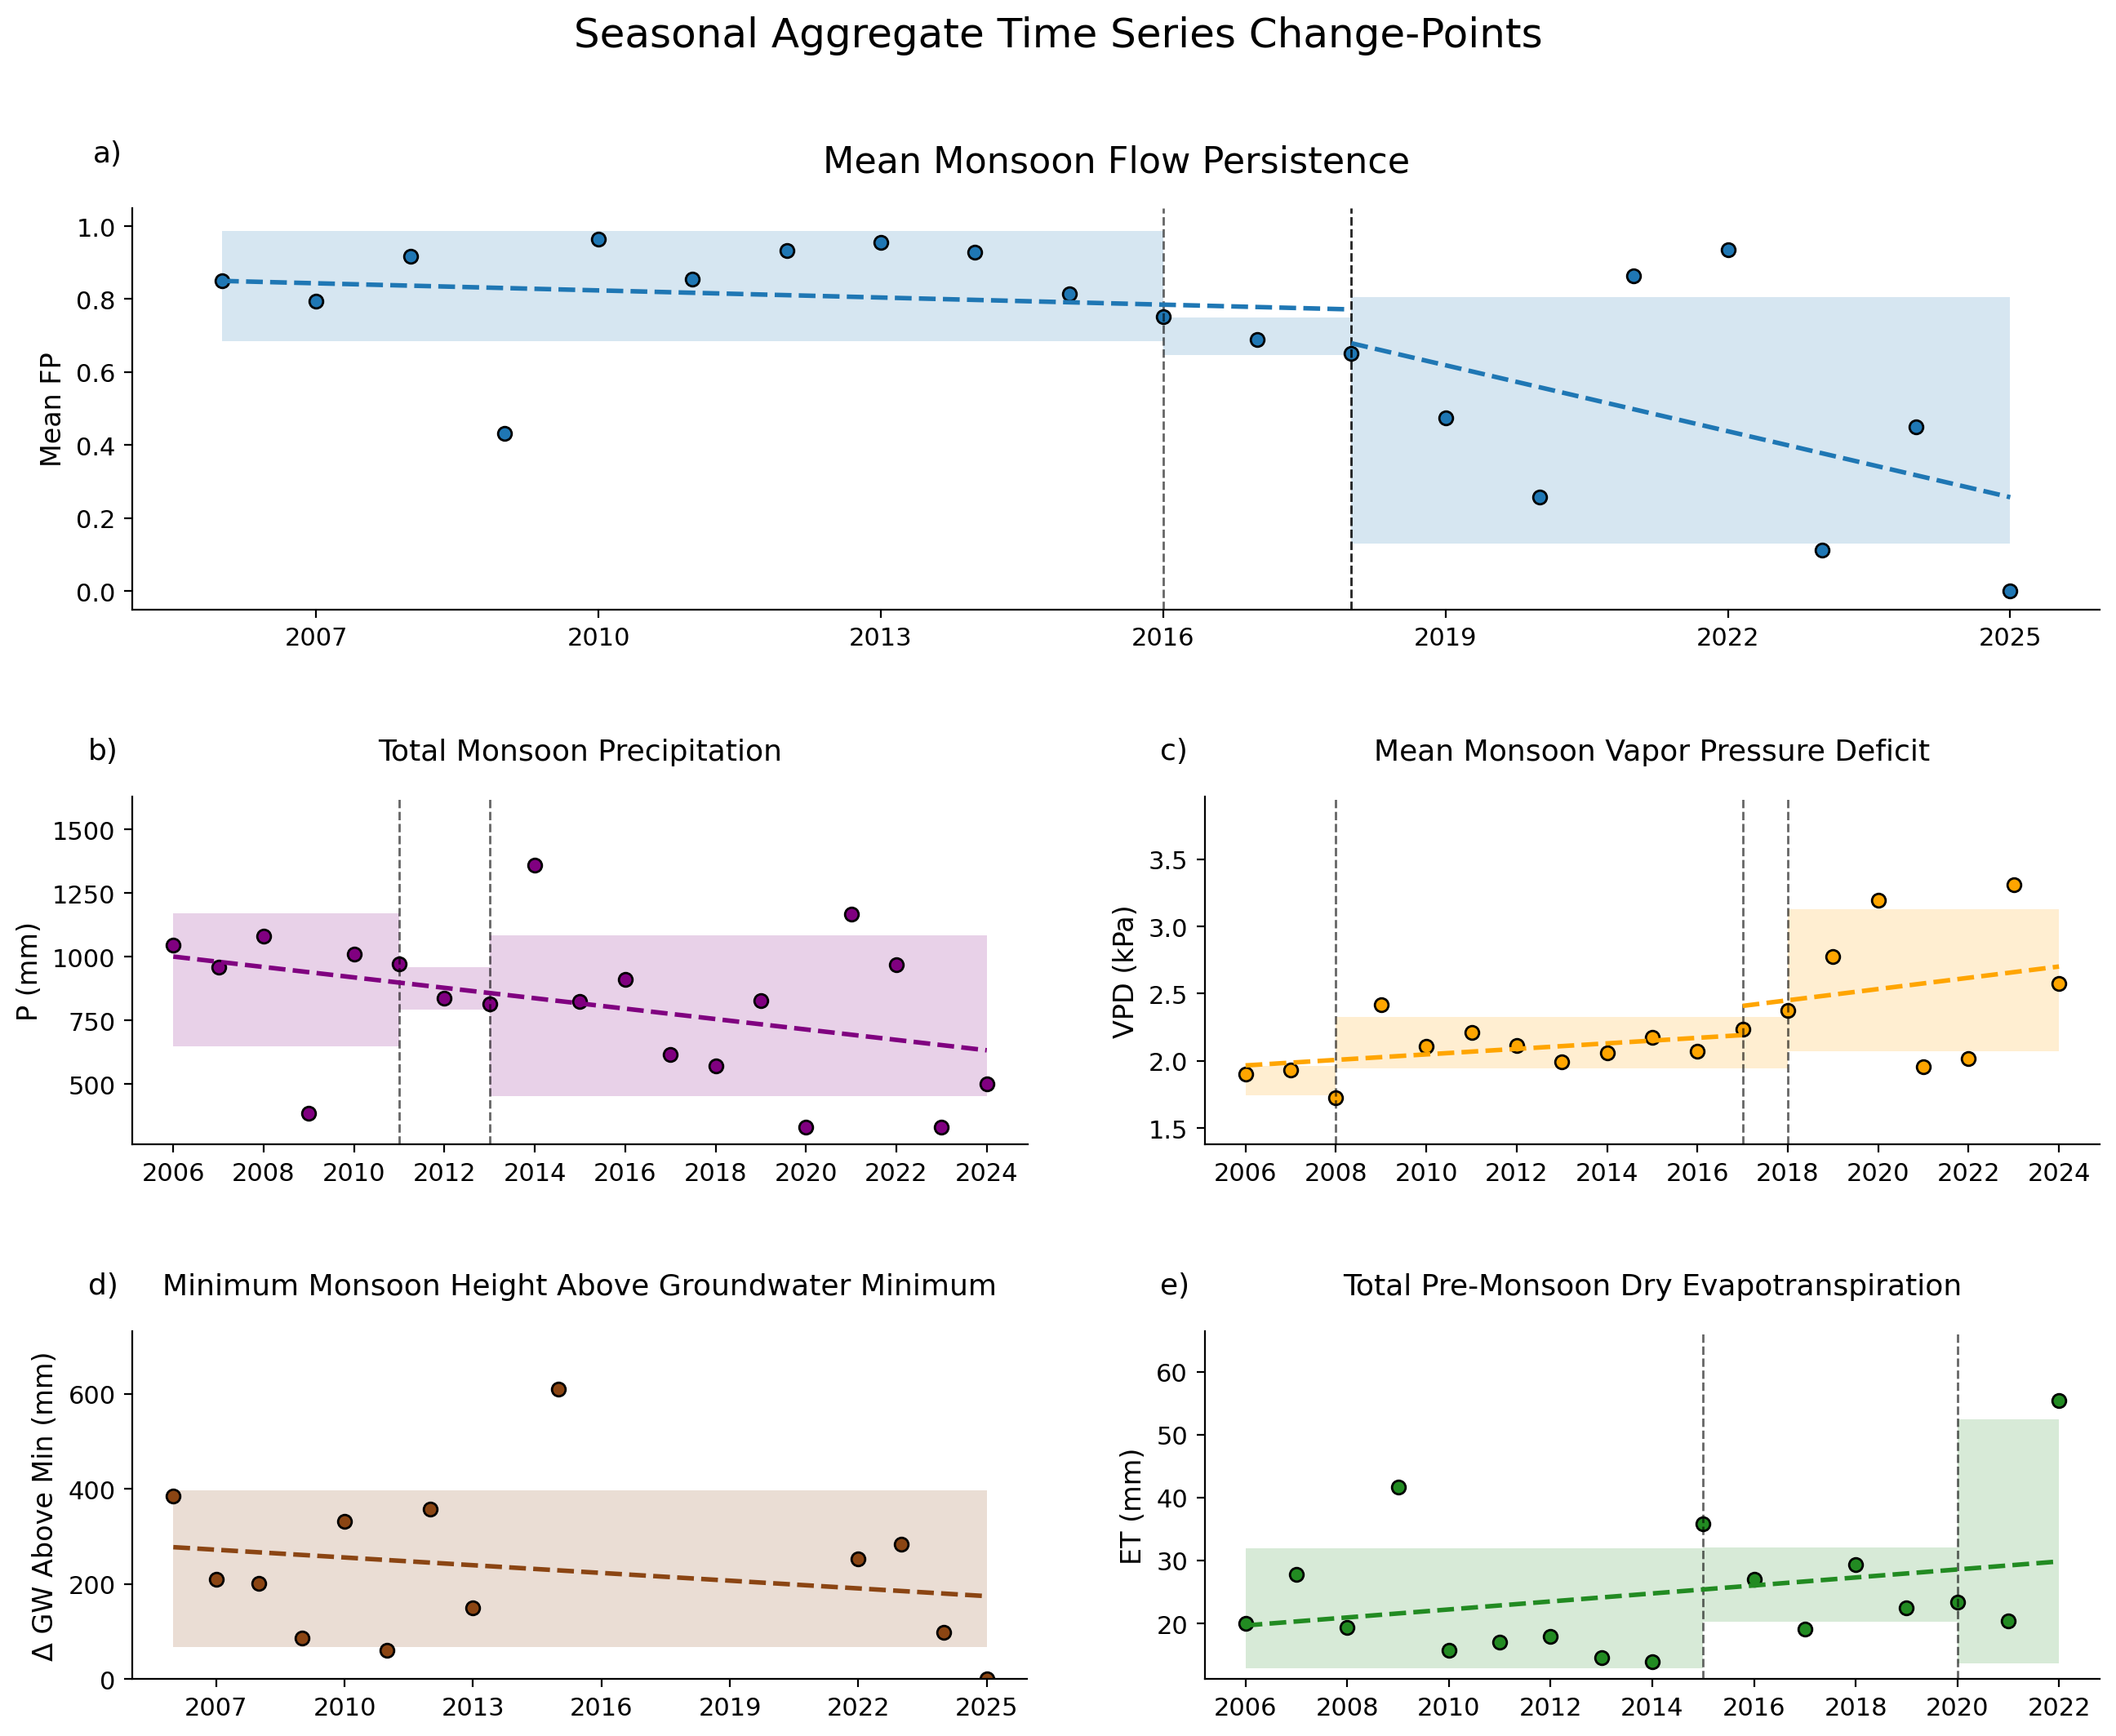

In [3]:
fig = plt.figure(figsize=(13, 10), constrained_layout=True)
fig.suptitle('Seasonal Aggregate Time Series Change-Points', fontsize=18, y=1.06)
gs = fig.add_gridspec(3, 2, height_ratios=[0.75, 0.65, 0.65])
ax_fp = fig.add_subplot(gs[0, :])
ax_precip = fig.add_subplot(gs[1, 0])
ax_vpd = fig.add_subplot(gs[1, 1])
ax_gw = fig.add_subplot(gs[2, 0])
ax_et = fig.add_subplot(gs[2, 1])

def panel_label(axis, label, x=-0.05):
    axis.text(
        x, 1.17, label, transform=axis.transAxes, ha='left', va='top',
        fontsize=13, clip_on=False,
    )

specs = [
    ('FP', 'Mean FP', 'tab:blue', ax_fp, 'Mean Monsoon Flow Persistence', 'a)'),
    ('precip', 'P (mm)', 'purple', ax_precip, 'Total Monsoon Precipitation', 'b)'),
    ('vpd', 'VPD (kPa)', 'orange', ax_vpd, 'Mean Monsoon Vapor Pressure Deficit', 'c)'),
    ('gw', 'Δ GW Above Min (mm)', 'saddlebrown', ax_gw, 'Minimum Monsoon Height Above Groundwater Minimum', 'd)'),
    ('et', 'ET (mm)', 'forestgreen', ax_et, 'Total Pre-Monsoon Dry Evapotranspiration', 'e)'),
]

for var, ylabel, color, ax, title, label in specs:
    df = series[series['variable'] == var].dropna(subset=['WY', 'value']).sort_values('WY')
    if df.empty:
        continue
    x = df['WY'].to_numpy(float)
    y = df['value'].to_numpy(float)
    ax.plot(x, y, linestyle='None', marker='o', markersize=6, markeredgecolor='black', markeredgewidth=1, markerfacecolor=color, color=color)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11, pad=16)
    panel_label(ax, label, x=-0.02 if ax is ax_fp else -0.05)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bp in breakpoints[breakpoints['variable'] == var]['bp_year']:
        ax.axvline(float(bp), color='black', linestyle='--', linewidth=1, alpha=0.6)
    for left, right, mean_value, sd_value in variance_bands(var):
        ax.add_patch(Rectangle((left, mean_value - sd_value), right - left, 2 * sd_value, facecolor=color, alpha=0.18, edgecolor='none'))
    for x_line, y_line, p_value in regression_lines(var):
        ax.plot(x_line, y_line, color=color, linewidth=2, linestyle='solid' if p_value < 0.05 else 'dashed')
    if var == 'FP':
        ax.set_ylim(-0.05, 1.05)
    else:
        lower = max(0, y.min() * 0.8) if var != 'gw' else y.min() * 0.9
        ax.set_ylim(lower, y.max() * 1.2)

for ax in [ax_fp, ax_precip, ax_vpd, ax_gw, ax_et]:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.tick_params(axis='both', labelsize=11, pad=4)
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.title.set_size(13 if ax is not ax_fp else 16)

for ax in [ax_precip, ax_vpd, ax_gw, ax_et]:
    ax.set_xlabel('')

fig.set_constrained_layout_pads(w_pad=0.12, h_pad=0.16, wspace=0.04, hspace=0.16)

%config InlineBackend.figure_format = "retina"

# fig.savefig('../Figures/CPD_monsoon.png', dpi=300, bbox_inches='tight')

In [4]:
def lag1_autocorr(residuals):
    if len(residuals) < 3:
        return np.nan
    return np.corrcoef(residuals[:-1], residuals[1:])[0, 1]

def effective_n(n, r1):
    if np.isnan(r1):
        return n
    r1 = np.clip(r1, -0.99, 0.99)
    n_eff = n * (1 - r1) / (1 + r1)
    return min(n, max(2, n_eff))

def adjusted_pvalue(r, n_eff):
    df = n_eff - 2
    if df < 1 or abs(r) >= 1:
        return np.nan
    t_stat = r * np.sqrt(df / (1 - r ** 2))
    return 2 * (1 - stats.t.cdf(abs(t_stat), df))

rows = []
for var in series['variable'].unique():
    df = series[series['variable'] == var].dropna(subset=['WY', 'value']).sort_values('WY')
    x = df['WY'].to_numpy(float)
    y = df['value'].to_numpy(float)
    cps = breakpoints[(breakpoints['variable'] == var) & (breakpoints['method'] == 'regression')]['bp_year'].tolist()
    bounds = [x.min()] + [float(cp) for cp in cps] + [x.max()]
    for left, right in zip(bounds[:-1], bounds[1:]):
        mask = (x >= left) & (x <= right)
        if mask.sum() < 3:
            continue
        xs, ys = x[mask], y[mask]
        slope, intercept, r, p_raw, _ = stats.linregress(xs, ys)
        residuals = ys - (intercept + slope * xs)
        r1 = lag1_autocorr(residuals)
        n_eff = effective_n(mask.sum(), r1)
        p_adj = adjusted_pvalue(r, n_eff)
        rows.append({
            'variable': var,
            'segment': f"{int(xs.min())}-{int(xs.max())}",
            'n': int(mask.sum()),
            'r': round(r, 3),
            'lag1 autocorr': round(r1, 3) if not np.isnan(r1) else np.nan,
            'n_eff': round(n_eff, 1),
            'p (raw)': round(p_raw, 4),
            'p (adjusted)': round(p_adj, 4) if not np.isnan(p_adj) else np.nan,
            'sig. changes': (p_raw < 0.05) != ((p_adj < 0.05) if not np.isnan(p_adj) else False),
        })

significance_table = pd.DataFrame(rows)
significance_table

,variable,segment,n,r,lag1 autocorr,n_eff,p (raw),p (adjusted),sig. changes
0,FP,2006-2018,13,-0.168,-0.107,13,0.5843,0.5843,False
1,FP,2018-2025,8,-0.437,-0.138,8,0.2789,0.2789,False
2,precip,2006-2024,19,-0.397,-0.213,19,0.0923,0.0923,False
3,vpd,2006-2017,12,0.411,-0.207,12,0.1845,0.1845,False
4,vpd,2017-2024,8,0.202,-0.195,8,0.6314,0.6314,False
5,gw,2006-2025,13,-0.227,-0.164,13,0.4560,0.4560,False
6,et,2006-2022,17,0.294,-0.173,17,0.2514,0.2514,False
